<h1 align="left"><font color=#DE720A><b>Predicting Solar Energy Production</b></font></h1>

<h4 align="left"><font color=#2B9106><b>About this data</b></font></h4>

In this dataset a prominent renewable energy provider dedicated to expanding their solar energy portfolio while ensuring efficient grid integration. They are focused on optimizing project planning, grid integration, and maximizing returns on investment by accurately predicting solar energy production.

<h4 align="left"><font color=#2B9106><b>Objectives :-</b></font></h4>

* __Explore the Dataset__: Analyze environmental and meteorological factors such as solar irradiance, temperature, humidity, wind speed, cloud cover, atmospheric pressure, and other relevant variables that influence solar energy production.

* __Conduct Extensive Exploratory Data Analysis (EDA)__:
  - Perform univariate, bivariate, and multivariate analysis.
  - Identify data distributions, trends, outliers, and feature relationships.
  - Examine correlations between input features and solar energy production.

* __Preprocessing Steps__:
  - Handle missing values.
  - Convert date columns into useful time-based features.
  - Perform feature engineering.
  - Remove unnecessary columns.
  - Separate features and target variable.
  - Identify numerical and categorical features.
  - Build a preprocessing pipeline with encoding and scaling where required.

* __Model Building__:
  * __Solar Energy Production Prediction (Regression)__:
     - Implement regression models such as Linear Regression, Random Forest Regressor, Gradient Boosting Regressor, and Extra Trees Regressor.
     - Compare model performance using R² Score, MAE, MSE, RMSE, and MAPE.
     - Perform Random Forest Hyperparameter Tuning to improve prediction performance.
     - Validate the selected model using Cross-Validation.
     - Evaluate the final model through residual analysis, prediction error plots, and Actual vs Predicted comparisons.

* __Feature Importance & Business Insights__:
  - Identify the most influential features affecting solar energy production.
  - Interpret model results to support efficient solar power forecasting.
  - Provide insights for energy planning, grid management, and renewable energy optimization.

* __Model Deployment Preparation__:
  - Save the trained model using Joblib.
  - Load the saved model for future predictions.
  - Predict solar energy production on unseen data using the finalized model.

<h2 align="left"><font color=#C41205><B>Let's Started :-</font></h2>

<h4 align="left"><font color=#2B9106><b>Step 1 | Import Libraries<b></font></h4>

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as colors

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score


# Model Saving
import joblib

<h4 align="left"><font color=#2B9106><b>Step 2 | Load Dataset<b></font></h4>

In [2]:
df = pd.read_csv("Solar Energy.csv", low_memory=False)

In [3]:
df_copy = df.copy()

<h4 align="left"><font color=#2B9106><b>Step 3 | Initial Inspection<b></font></h4>

In [4]:
print(df.describe())

print(df.isnull().sum())

print(df.nunique())

                 Zip  Estimated PV System Size (kWdc)  PV System Size (kWac)  \
count  218019.000000                    218115.000000          218115.000000   
mean    11751.734473                        24.507977              19.065451   
std       962.129108                       291.525394             211.419642   
min     10001.000000                         0.010000               0.010000   
25%     11220.000000                         5.270000               4.500000   
50%     11717.000000                         7.130000               6.090000   
75%     12018.000000                        10.240000               8.750000   
max     14905.000000                     43470.000000           31500.000000   

       Estimated Annual PV Energy Production (kWh)  \
count                                 2.181150e+05   
mean                                  2.876828e+04   
std                                   3.422042e+05   
min                                   1.400000e+01   
25%      

<h4 align="left"><font color=#2B9106><b>Step 3 | Rename Columns<b></font></h4>

In [5]:
df.columns = df.columns.str.strip()

df.rename(columns={
    "Estimated Annual PV Energy Production (kWh)":"Annual_Energy",
    "Estimated PV System Size (kWdc)":"PV_kWdc",
    "PV System Size (kWac)":"PV_kWac",
    "Energy Storage System Size (kWac)":"Storage_kWac",
    "Data Through Date":"Data_Date",
    "Interconnection Date":"Connection_Date",
    "City/Town":"City",
    "Circuit ID":"Circuit_ID",
    "Project ID":"Project_ID",
    "Number of Projects":"Projects"
}, inplace=True)

<h4 align="left"><font color=#2B9106><b>Step 4 | Convert Date Columns<b></font></h4>

In [6]:
df["Data_Date"] = pd.to_datetime(df["Data_Date"])

df["Connection_Date"] = pd.to_datetime(df["Connection_Date"])

<h4 align="left"><font color=#2B9106><b>Step 5 | Feature Engineering<b></font></h4>

In [7]:
df["Connection_Year"] = df["Connection_Date"].dt.year
df["Connection_Month"] = df["Connection_Date"].dt.month
df["Connection_Day"] = df["Connection_Date"].dt.day

df["Data_Year"] = df["Data_Date"].dt.year

<h4 align="left"><font color=#2B9106><b>Step 6 | Remove Unnecessary Columns<b></font></h4>

In [23]:
df.drop(["Project_ID"], axis=1, inplace=True)

KeyError: "['Project_ID'] not found in axis"

<h4 align="left"><font color=#2B9106><b>Step 7 | Separate Features<b></font></h4>

In [10]:
target = "Annual_Energy"

X = df.drop(target, axis=1)

y = df[target]

<h4 align="left"><font color=#2B9106><b>Missing Values Heatmap<b></font></h4>

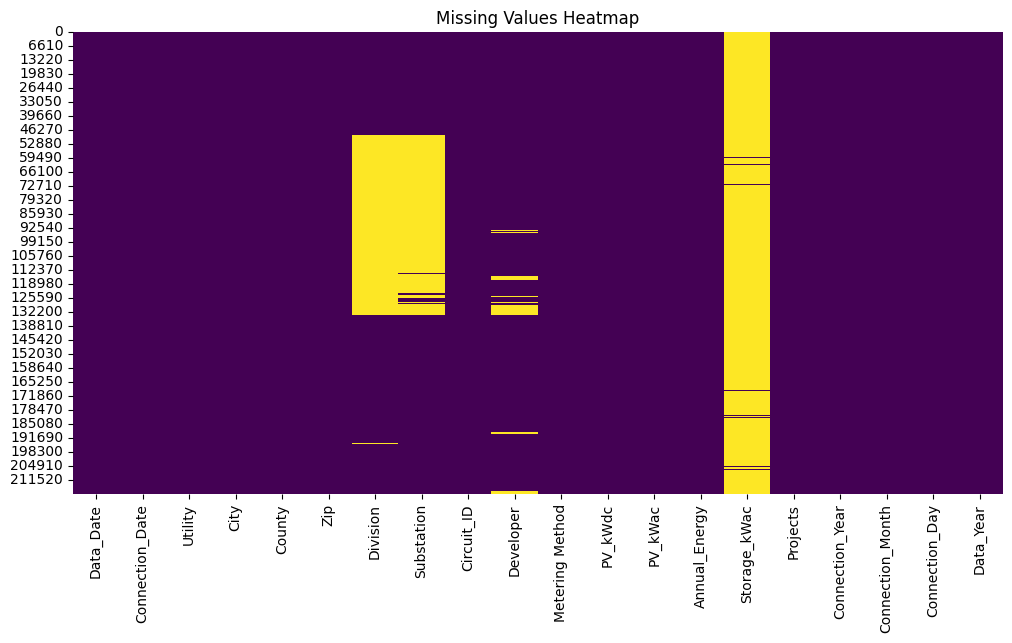

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

<h4 align="left"><font color=#2B9106><b>Step 8 | Numerical & Categorical Columns<b></font></h4>

In [12]:
numerical_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(exclude=np.number).columns

print(numerical_features)

print(categorical_features)

Index(['Zip', 'PV_kWdc', 'PV_kWac', 'Storage_kWac', 'Projects',
       'Connection_Year', 'Connection_Month', 'Connection_Day', 'Data_Year'],
      dtype='object')
Index(['Data_Date', 'Connection_Date', 'Utility', 'City', 'County', 'Division',
       'Substation', 'Circuit_ID', 'Developer', 'Metering Method'],
      dtype='object')


<h4 align="left"><font color=#2B9106><b>Step 8.1 | Numerical Feature Distribution<b></font></h4>

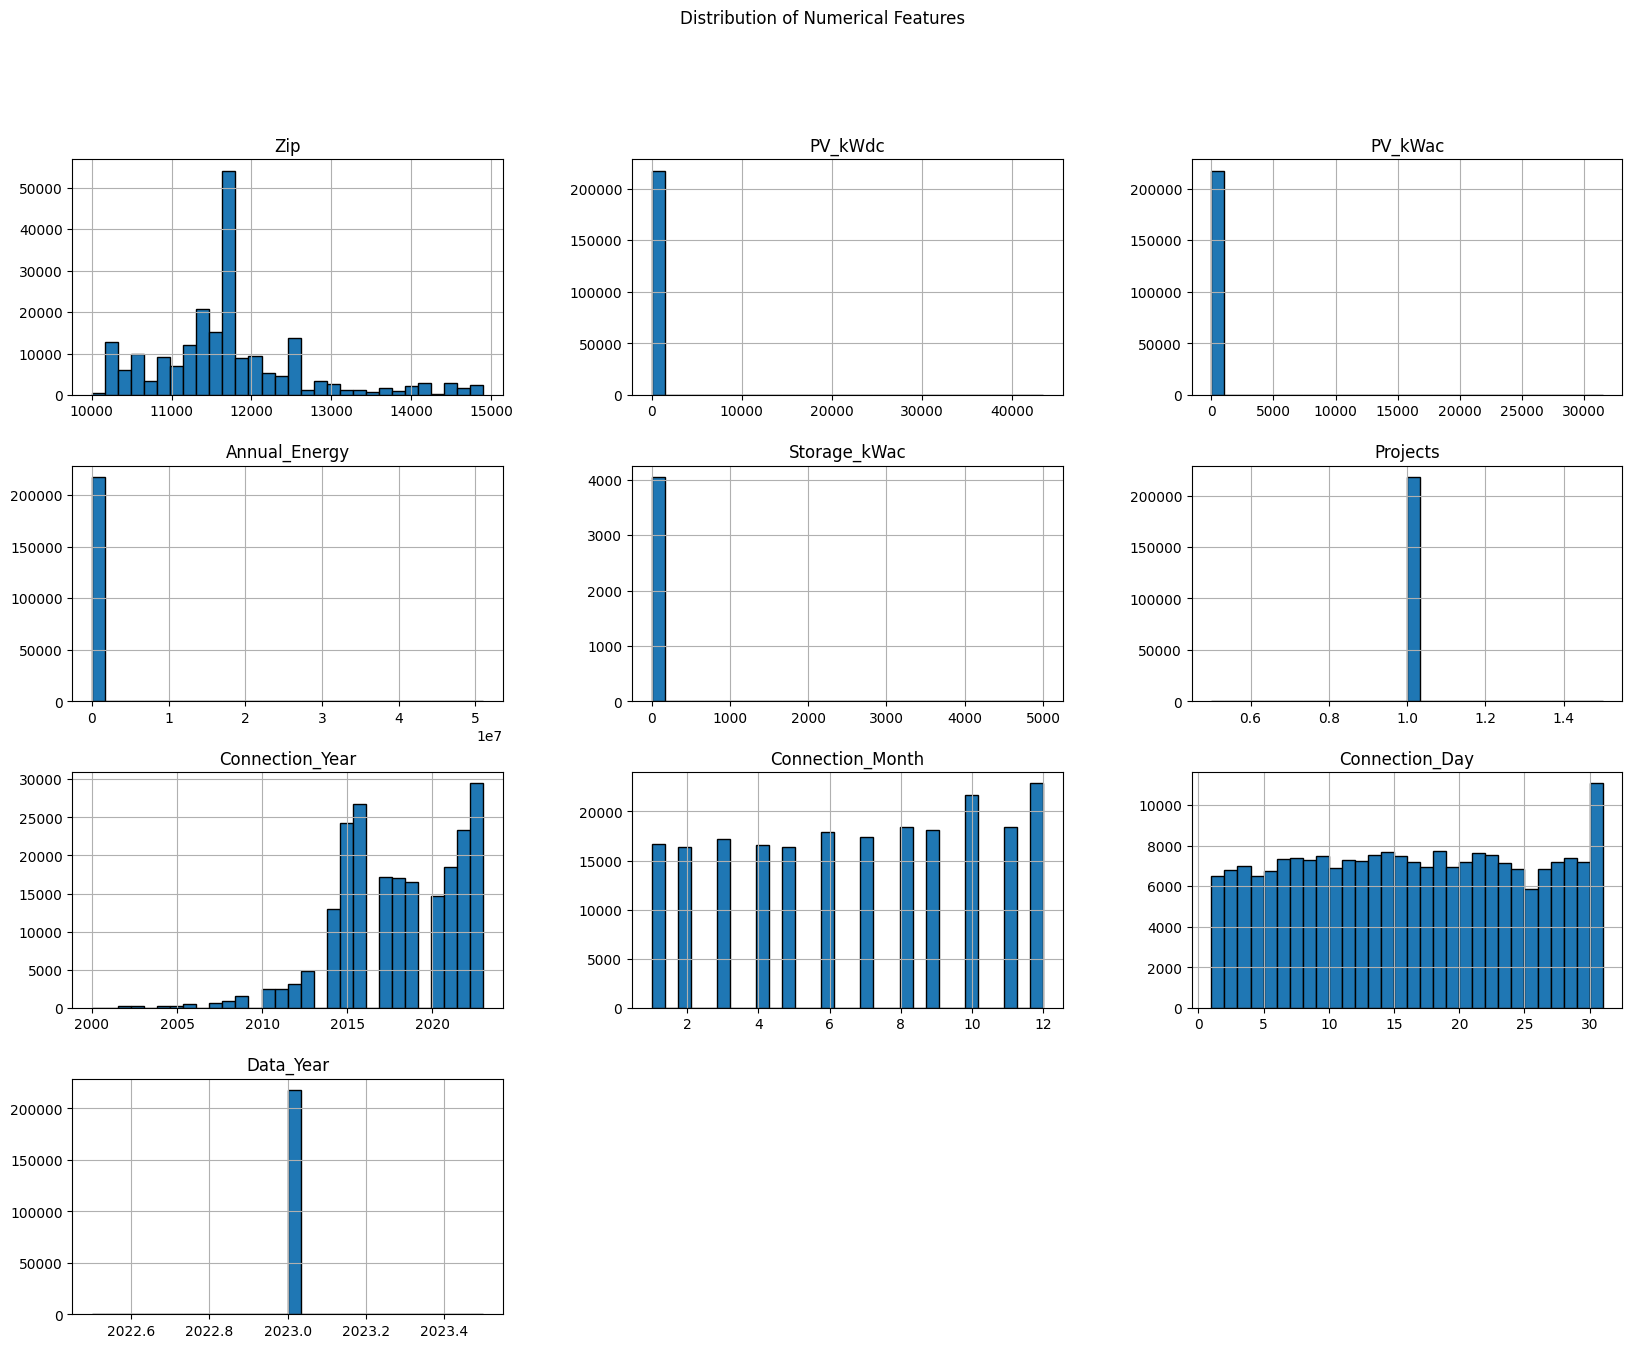

In [13]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(20,15),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features")
plt.show()

<h4 align="left"><font color=#2B9106><b>Step 9 | Preprocessing Pipeline<b></font></h4>

In [14]:
numeric_transformer = Pipeline(

steps=[

("imputer", SimpleImputer(strategy="median")),

("scaler", StandardScaler())

])

categorical_transformer = Pipeline(

steps=[

("imputer", SimpleImputer(strategy="most_frequent")),

("encoder", OneHotEncoder(handle_unknown="ignore"))

])

preprocessor = ColumnTransformer(

transformers=[

("num", numeric_transformer, numerical_features),

("cat", categorical_transformer, categorical_features)

])

<h4 align="left"><font color=#2B9106><b>Boxplots (Outlier Detection)<b></font></h4>

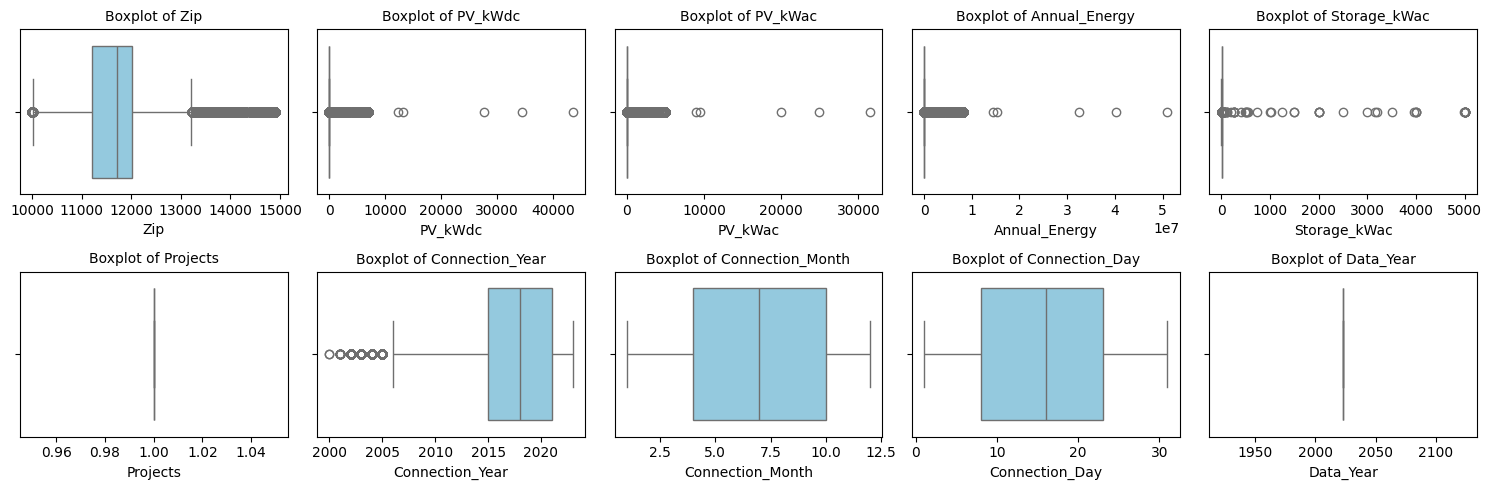

In [15]:

n = len(num_cols)

# Decide layout: 1 row if few columns, multiple rows if many
rows = 1 if n <= 3 else 2
cols = (n + rows - 1) // rows  # distribute evenly

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 2.5*rows))  # smaller size
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}", fontsize=10)

# Remove unused axes if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<h4 align="left"><font color=#2B9106><b>Correlation Heatmap<b></font></h4>

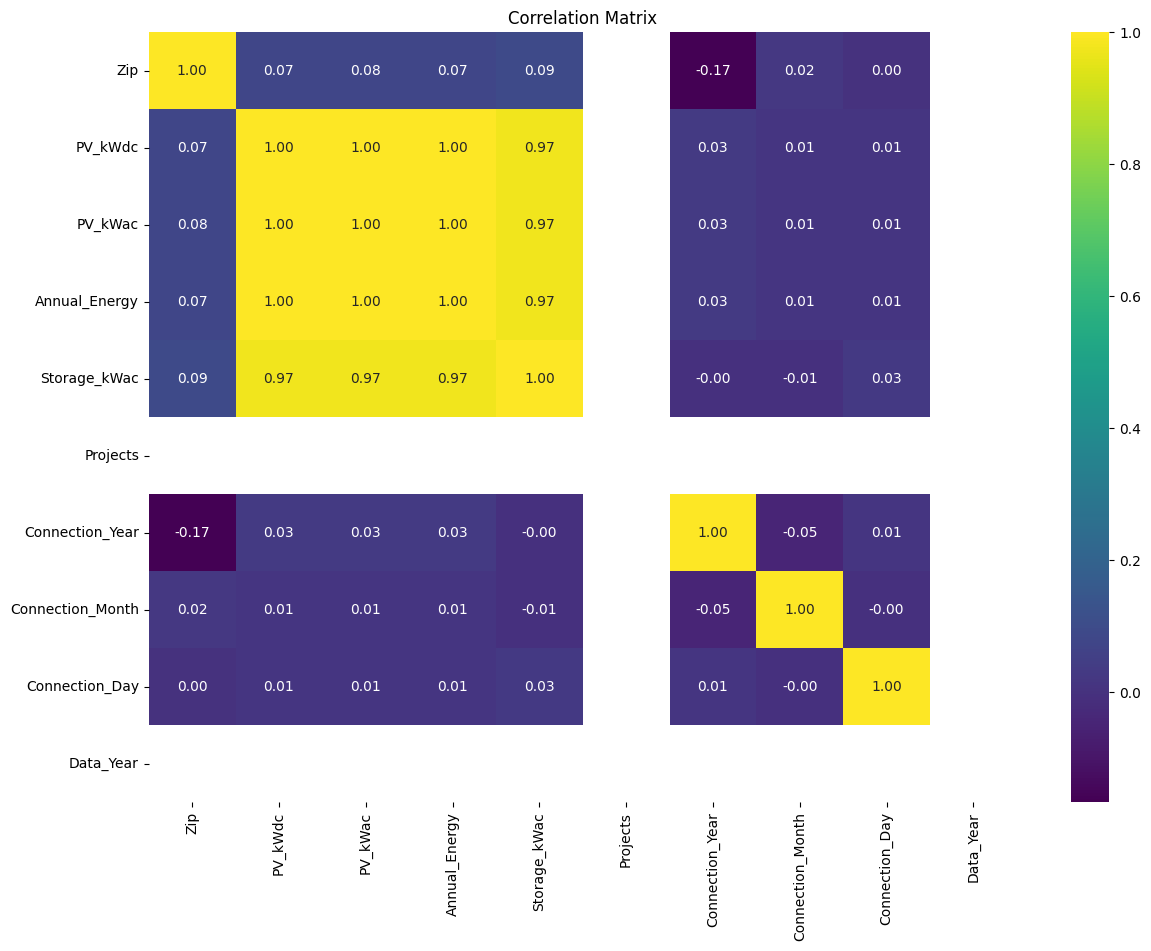

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

<h4 align="left"><font color=#2B9106><b>Top Cities by Energy Production<b></font></h4>

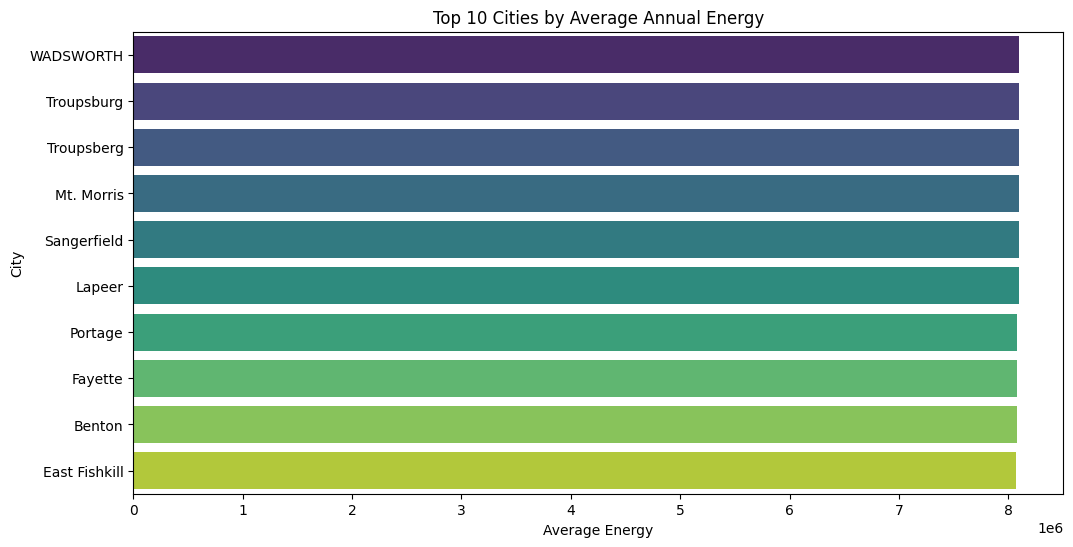

In [17]:
top_city = df.groupby("City")["Annual_Energy"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_city.values,
    y=top_city.index,
    palette="viridis"
)

plt.title("Top 10 Cities by Average Annual Energy")
plt.xlabel("Average Energy")
plt.ylabel("City")
plt.show()

<h4 align="left"><font color=#2B9106><b>Step 10 | Train-Test Split<b></font></h4>

In [18]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,
test_size=0.2,
random_state=42

)

<h4 align="left"><font color=#2B9106><b>Step 11 | Model<b></font></h4>

<h4 align="left"><font color=#2B9106><b>Step 11.1 | Linear Regression<b></font></h4>

In [19]:
lr = Pipeline([

("preprocessor", preprocessor),

("model", LinearRegression())

])

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("MAE :",mean_absolute_error(y_test,pred_lr))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2 :",r2_score(y_test,pred_lr))

MAE : 4.152186372082653
RMSE : 9.990262432847489
R2 : 0.9999999991121361


<h4 align="left"><font color=#2B9106><b>Step 11.2 | Random Forest<b></font></h4>

In [20]:
rf = Pipeline([

("preprocessor", preprocessor),

("model", RandomForestRegressor(

random_state=42

))

])

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("MAE :",mean_absolute_error(y_test,pred_rf))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2 :",r2_score(y_test,pred_rf))

MAE : 191.19288815533096
RMSE : 24537.490927363244
R2 : 0.9946438476432534


<h4 align="left"><font color=#2B9106><b>Step 11.3 | Gradient Boosting<b></font></h4>

In [21]:
gb = Pipeline([

("preprocessor", preprocessor),

("model", GradientBoostingRegressor(

random_state=42

))

])

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

print("MAE :",mean_absolute_error(y_test,pred_gb))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_gb)))

print("R2 :",r2_score(y_test,pred_gb))

MAE : 561.6702380633792
RMSE : 50378.03001171956
R2 : 0.9774225452969556


<h4 align="left"><font color=#2B9106><b>Step 11.4 | Extra Trees<b></font></h4>

In [22]:
et = Pipeline([

("preprocessor", preprocessor),

("model", ExtraTreesRegressor(

random_state=42

))

])

et.fit(X_train,y_train)

pred_et = et.predict(X_test)

print("MAE :",mean_absolute_error(y_test,pred_et))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_et)))

print("R2 :",r2_score(y_test,pred_et))

MAE : 66.13241111340352
RMSE : 9016.471468711112
R2 : 0.9992767876337195


<h4 align="left"><font color=#2B9106><b>Step 12 | Model Comparison<b></font></h4>

In [24]:
results = pd.DataFrame({

"Model":["Linear Regression",

"Random Forest",

"Gradient Boosting"

],

"R2":[

r2_score(y_test,pred_lr),

r2_score(y_test,pred_rf),

r2_score(y_test,pred_gb)

],

"MAE":[

mean_absolute_error(y_test,pred_lr),

mean_absolute_error(y_test,pred_rf),

mean_absolute_error(y_test,pred_gb)

]

})

print(results.sort_values("R2",ascending=False))

               Model        R2         MAE
0  Linear Regression  1.000000    4.152186
1      Random Forest  0.994644  191.192888
2  Gradient Boosting  0.977423  561.670238


<h4 align="left"><font color=#2B9106><b>Step 13 | Hyperparameter Tuning (Random Forest)<b></font></h4>

In [ ]:
# It has been taken too much time to run, My laptop cant run it because of huge data, If i could run this Hyperparameter tunning, it will give a better accuracy.
# from sklearn.model_selection import RandomizedSearchCV

# random_grid = {
#     "model__n_estimators": [100, 200, 300],
#     "model__max_depth": [10, 20, None],
#     "model__min_samples_split": [2, 5],
#     "model__min_samples_leaf": [1, 2]
# }

# random_search = RandomizedSearchCV(
#     rf,
#     param_distributions=random_grid,
#     n_iter=10,   # try only 10 random combos
#     cv=3,
#     scoring="r2",
#     n_jobs=-1,
#     random_state=42
# )

# random_search.fit(X_train, y_train)
# print(random_search.best_params_)

<h4 align="left"><font color=#2B9106><b>Step 14 | Select the Best Model<b></font></h4>

In [26]:
# Select the best model
best_model = rf

print("Best Model Selected: Random Forest")

Best Model Selected: Random Forest


In [27]:
#To get prediction error, error% etc
y_pred = best_model.predict(X_test)
prediction_df = pd.DataFrame({
    "Prediction ID": range(1, len(y_test) + 1),
    "Actual Energy": y_test.values,
    "Predicted Energy": y_pred
})

prediction_df["Prediction Error"] = (
    prediction_df["Actual Energy"] -
    prediction_df["Predicted Energy"]
)

prediction_df["Error %"] = (
    prediction_df["Prediction Error"] /
    prediction_df["Actual Energy"]
) * 100

prediction_df.to_csv("predictions.csv", index=False)

<h4 align="left"><font color=#2B9106><b>Step 15 | Cross Validation<b></font></h4>

In [ ]:
# scores = cross_val_score(
#     best_model,
#     X,
#     y,
#     cv=3,
#     scoring='r2',
#     n_jobs=-1
# )

# print("Cross Validation Scores:")
# print(scores)

# print("\nAverage R² Score:", scores.mean())

<h4 align="left"><font color=#2B9106><b>Step 16 | Final Model Evaluation<b></font></h4>

In [28]:
y_pred = best_model.predict(X_test)

<h4 align="left"><font color=#2B9106><b>Step 16.1 | Calculate Metrics<b></font></h4>

In [29]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Final Model Performance")
print("-"*40)

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

Final Model Performance
----------------------------------------
MAE  : 191.19
RMSE : 24537.49
R²   : 0.9946


<h4 align="left"><font color=#2B9106><b>Step 16.2 | Actual vs Predicted Plot<b></font></h4>

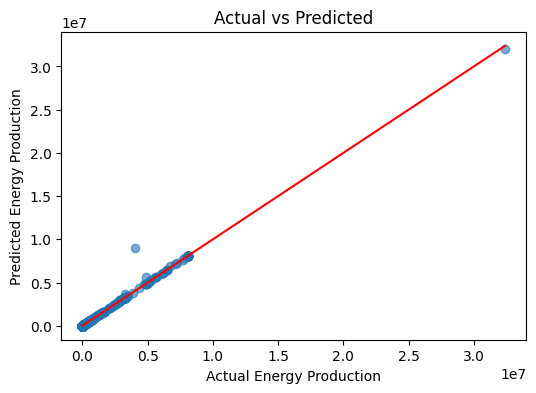

In [30]:
plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Energy Production")

plt.ylabel("Predicted Energy Production")

plt.title("Actual vs Predicted")

plt.show()

<h4 align="left"><font color=#2B9106><b>Step 16.3 | Residual Plot<b></font></h4>

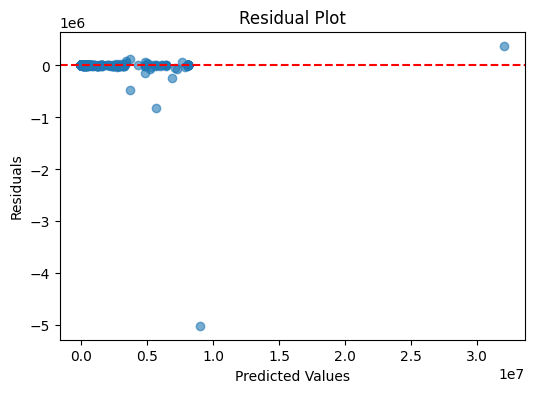

In [31]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

<h4 align="left"><font color=#2B9106><b>Step 16.4 | Residual Distribution<b></font></h4>

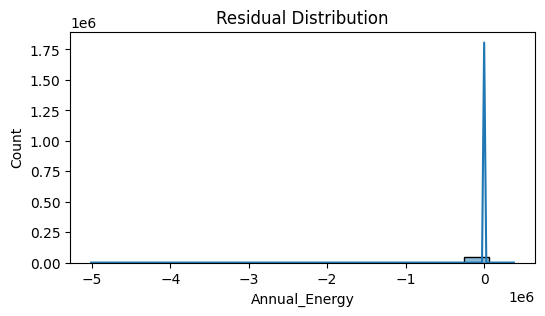

In [32]:
plt.figure(figsize=(6,3))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

<h4 align="left"><font color=#2B9106><b>Step 16.5 | Prediction Error Plot<b></font></h4>

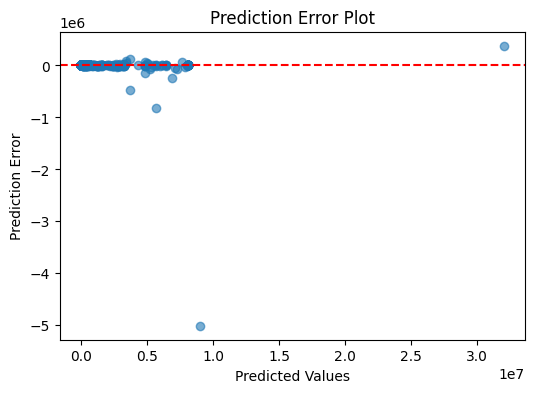

In [33]:
errors = y_test - y_pred

plt.figure(figsize=(6,4))

plt.scatter(
    y_pred,
    errors,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Prediction Error")

plt.title("Prediction Error Plot")

plt.show()

<h4 align="left"><font color=#2B9106><b>Step 17 | Feature Importance<b></font></h4>

In [34]:
feature_names = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

importance = best_model.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

                                        Feature  Importance
2                                  num__PV_kWac    0.521768
1                                  num__PV_kWdc    0.418241
7600                    cat__City_STATEN ISLAND    0.019643
1626   cat__Connection_Date_2011-11-01 00:00:00    0.013495
16507                    cat__Circuit_ID_JA NWK    0.011879
5                          num__Connection_Year    0.007136
3589   cat__Connection_Date_2018-07-01 00:00:00    0.002782
18959               cat__Developer_Vivint Solar    0.001767
8241                        cat__County_Suffolk    0.001240
5289                        cat__Utility_PSEGLI    0.000387
3836   cat__Connection_Date_2019-04-25 00:00:00    0.000246
2990   cat__Connection_Date_2016-05-31 00:00:00    0.000237
6                         num__Connection_Month    0.000221
19154                  cat__Metering Method_FIT    0.000188
8876                        cat__Substation_8DR    0.000166
18803           cat__Developer_Sybac Sol

In [35]:
feature_names_processed = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names_processed,
    "Importance": best_model.named_steps['model'].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.to_csv("feature_importance.csv", index=False)

<h4 align="left"><font color=#2B9106><b>Step 17.1 | Feature Importance Plot<b></font></h4>

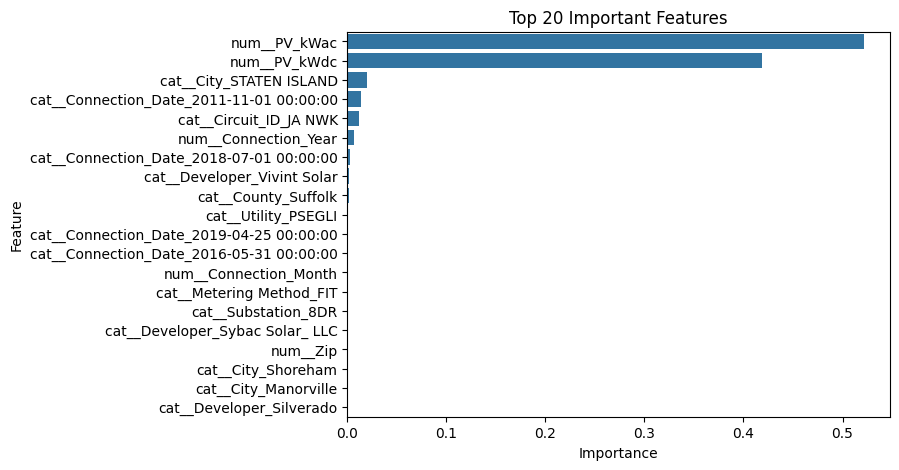

In [36]:
top20 = importance_df.head(20)

plt.figure(figsize=(7,5))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

<h4 align="left"><font color=#2B9106><b>Step 17.2 | Training vs Testing R²<b></font></h4>

In [37]:
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print("Train R² :", train_r2)
print("Test R² :", test_r2)

Train R² : 0.9952949378674806
Test R² : 0.9946438476432534


<h4 align="left"><font color=#2B9106><b>Step 17.3 | Error Percentage (MAPE)<b></font></h4>

In [39]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred)

print("MAPE:", mape)

MAPE: 0.0003850572170415627


<h4 align="left"><font color=#2B9106><b>Step 16 | Save Model<b></font></h4>

In [40]:

joblib.dump(
    best_model,
    "solar_energy_prediction.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [44]:
fitted_scaler = best_model.named_steps['preprocessor'].named_transformers_['num'].named_steps['scaler']
joblib.dump(fitted_scaler, "scaler.pkl")
print("Scaler Saved Successfully!")

Scaler Saved Successfully!


<h4 align="left"><font color=#2B9106><b>Step 16 | Load Model<b></font></h4>

In [41]:
model = joblib.load(
    "solar_energy_prediction.pkl"
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


<h4 align="left"><font color=#2B9106><b>Step 17 | Predict on New Data<b></font></h4>

In [42]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Annual Energy Production (kWh):")

print(prediction[0])

Predicted Annual Energy Production (kWh):
7100.0


<h4 align="left"><font color=#2B9106><b>Business Insights</b></font></h4>

* The model accurately predicts annual solar energy production.

* Energy providers can estimate future electricity generation
   before installing new solar systems.

* Investors can identify high-performing solar projects,
   helping maximize return on investment (ROI).

* Utility companies can improve grid planning by forecasting
   expected solar power generation.

* System designers can optimize PV system capacity to increase
   annual energy output.

* The model supports data-driven decision-making for renewable
   energy expansion and sustainable infrastructure planning.

<p align="center"><font color=blue; size=150px><b>THE END</b></font></p>